# Oracle Prior — Log-Linear Scaling Law

Tests whether attention entropy at prefill follows:
```
target ≈ a − b · log2(ctx_len)
```
across context lengths, tasks (qa_1, qa_2), and models (LLaMA 3.1-8B, Qwen3.5-2B).

**Analyses:**
1. Fit log-linear model per series; compare slopes
2. Hold-out validation: fit on 4k+8k only → predict 16k, 32k, 65k
3. 131k outlier detection via residual from fit
4. Export blended controller-ready `oracle_prior_blended.json`

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from collections import defaultdict

ORACLE_DIR = Path('/c2/jenny/r3/oracle_prior')
OUT_DIR    = Path('/c2/jenny/r3/oracle_prior')

# Bins to treat as valid (exclude 131k for fitting; include for outlier plot)
FIT_BINS  = [4096, 8192, 16384, 32768, 65536]
ALL_BINS  = [4096, 8192, 16384, 32768, 65536, 131072]

## 1. Load data

In [3]:
def load_oracle_json(path):
    """Load oracle_prior_*.json → {bin_int: {mean, std, n}}"""
    with open(path) as f:
        d = json.load(f)
    out = {}
    for k, v in d['bins'].items():
        if k.startswith('>') or v['mean'] is None:
            continue
        out[int(k)] = {'mean': v['mean'], 'std': v['std'], 'n': v['n']}
    return out

def load_samples_jsonl(path):
    """Load oracle_prior_samples.jsonl → {bin_int: [attn_entropy_mean, ...]}"""
    rows = [json.loads(l) for l in open(path) if l.strip()]
    bins = defaultdict(list)
    for r in rows:
        label = r['bin_label']
        if label.startswith('>'):
            continue
        bins[int(label)].append(r['attn_entropy_mean'])
    return {k: {'mean': np.mean(v), 'std': np.std(v), 'n': len(v)}
            for k, v in bins.items()}

series = {
    'LLaMA qa_1': load_oracle_json(ORACLE_DIR / 'llama31_8b_ruler/oracle_prior_qa1.json'),
    'LLaMA qa_2': load_oracle_json(ORACLE_DIR / 'llama31_8b_ruler/oracle_prior_qa2.json'),
    # 'Qwen qa_1':  load_samples_jsonl(ORACLE_DIR / 'qwen35_2b_ruler/oracle_prior_samples.jsonl'),
}

for name, data in series.items():
    print(f'\n{name}:')
    for b in sorted(data):
        d = data[b]
        print(f'  {b:>7}  mean={d["mean"]:.6f}  std={d["std"]:.6f}  n={d["n"]}')


LLaMA qa_1:
     4096  mean=0.342064  std=0.011011  n=200
     8192  mean=0.324095  std=0.015529  n=200
    16384  mean=0.298129  std=0.009009  n=200
    32768  mean=0.287364  std=0.008339  n=200
    65536  mean=0.283448  std=0.008387  n=200
   131072  mean=0.349918  std=0.006777  n=200

LLaMA qa_2:
     4096  mean=0.315772  std=0.008349  n=200
     8192  mean=0.298466  std=0.006897  n=200
    16384  mean=0.280914  std=0.006322  n=200
    32768  mean=0.270954  std=0.005629  n=200
    65536  mean=0.269249  std=0.005491  n=200
   131072  mean=0.340939  std=0.005209  n=200


## 2. Fit log-linear model on all valid bins (4k–65k)

In [ ]:
def fit_log_linear(data, fit_bins):
    """
    Fit target = a - b * log2(ctx_len) via least squares.
    Returns (a, b, r2, residuals_dict).
    """
    xs = np.array([np.log2(b) for b in fit_bins if b in data])
    ys = np.array([data[b]['mean'] for b in fit_bins if b in data])
    bins_used = [b for b in fit_bins if b in data]

    # polyfit: ys = p[0]*xs + p[1]  →  a=p[1], b=-p[0]
    p = np.polyfit(xs, ys, 1)
    b_coef = -p[0]   # slope magnitude (positive = decreasing with length)
    a_coef =  p[1]   # intercept

    y_pred = np.polyval(p, xs)
    ss_res = np.sum((ys - y_pred) ** 2)
    ss_tot = np.sum((ys - ys.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    residuals = {bins_used[i]: float(ys[i] - y_pred[i]) for i in range(len(bins_used))}
    return float(a_coef), float(b_coef), float(r2), residuals, p

fits = {}
print(f"{'Series':<15}  {'a':>8}  {'b (per doubling)':>18}  {'R^2':>6}")
print('-' * 55)
for name, data in series.items():
    a, b, r2, resid, p = fit_log_linear(data, FIT_BINS)
    fits[name] = (a, b, r2, resid, p)
    print(f'{name:<15}  {a:>8.6f}  {-b:>18.6f}  {r2:>6.4f}')

Series                  a    b (per doubling)     R^2
-------------------------------------------------------
LLaMA qa_1       0.522568           -0.015396  0.9330
LLaMA qa_2       0.455852           -0.012056  0.9264


## 3. Hold-out validation — fit on 4k+8k, predict 16k/32k/65k

In [10]:
HOLDOUT_TRAIN = [4096, 8192]
HOLDOUT_TEST  = [16384, 32768, 65536]

print('Hold-out validation (train=4k+8k)\n')
print(f"{'Series':<15}  {'bin':>7}  {'measured':>10}  {'predicted':>10}  {'error':>8}  {'error/std':>10}")
print('-' * 70)

for name, data in series.items():
    a_ho, b_ho, r2_ho, _, p_ho = fit_log_linear(data, HOLDOUT_TRAIN)
    for b in HOLDOUT_TEST:
        if b not in data:
            continue
        measured  = data[b]['mean']
        predicted = float(np.polyval(p_ho, np.log2(b)))
        error     = measured - predicted
        err_std   = error / data[b]['std'] if data[b]['std'] > 0 else float('nan')
        print(f'{name:<15}  {b:>7}  {measured:>10.6f}  {predicted:>10.6f}  {error:>+8.6f}  {err_std:>+10.3f}')
    print()

Hold-out validation (train=4k+8k)

Series               bin    measured   predicted     error   error/std
----------------------------------------------------------------------
LLaMA qa_1         16384    0.298129    0.306126  -0.007997      -0.888
LLaMA qa_1         32768    0.287364    0.288157  -0.000793      -0.095
LLaMA qa_1         65536    0.283448    0.270188  +0.013260      +1.581

LLaMA qa_2         16384    0.280914    0.281160  -0.000246      -0.039
LLaMA qa_2         32768    0.270954    0.263854  +0.007100      +1.261
LLaMA qa_2         65536    0.269249    0.246548  +0.022701      +4.134



## 4. 131k outlier detection

In [12]:
print('131k outlier check (deviation from trend fit on 4k–65k)\n')
print(f"{'Series':<15}  {'measured':>10}  {'predicted':>10}  {'deviation':>10}  {'z-score':>8}")
print('-' * 60)

for name, data in series.items():
    if 131072 not in data:
        print(f'{name:<15}  (no 131k data)')
        continue
    _, _, _, resid, p = fits[name]
    measured  = data[131072]['mean']
    predicted = float(np.polyval(p, np.log2(131072)))
    deviation = measured - predicted

    # z-score relative to residual std on fit bins
    resid_vals = np.array(list(resid.values()))
    z = deviation / resid_vals.std() if resid_vals.std() > 0 else float('nan')
    print(f'{name:<15}  {measured:>10.6f}  {predicted:>10.6f}  {deviation:>+10.6f}  {z:>+8.2f}σ')

131k outlier check (deviation from trend fit on 4k–65k)

Series             measured   predicted   deviation   z-score
------------------------------------------------------------
LLaMA qa_1         0.349918    0.260831   +0.089087    +15.27σ
LLaMA qa_2         0.340939    0.250904   +0.090035    +18.74σ


## 5. Plot

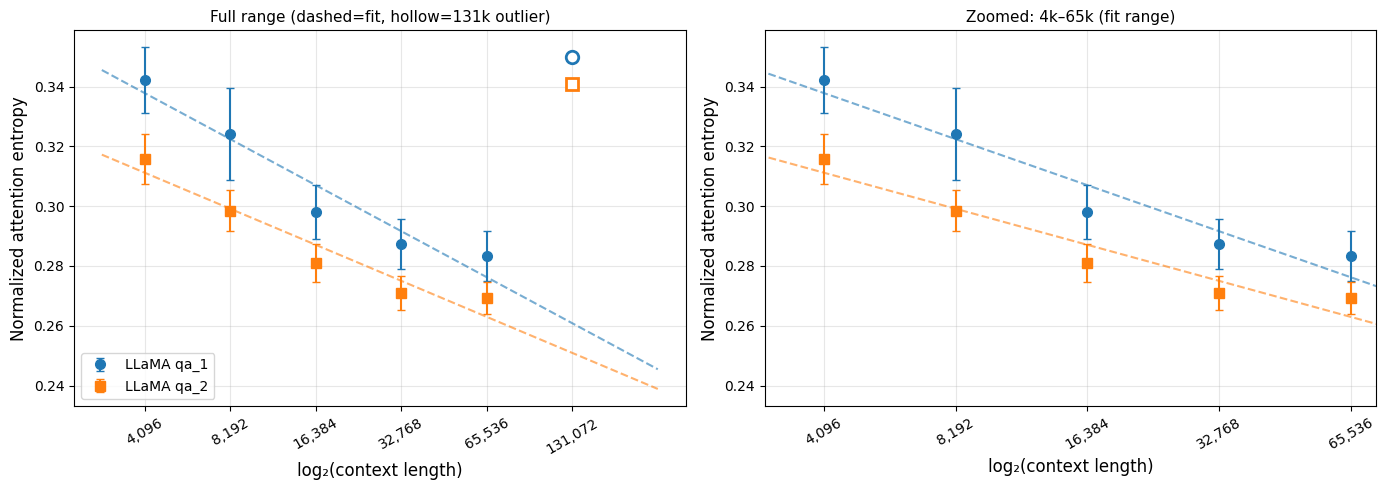

Saved: /c2/jenny/r3/oracle_prior/scaling_law_fit.png


In [13]:
colors = {'LLaMA qa_1': '#1f77b4', 'LLaMA qa_2': '#ff7f0e', 'Qwen qa_1': '#2ca02c'}
markers = {'LLaMA qa_1': 'o', 'LLaMA qa_2': 's', 'Qwen qa_1': '^'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Smooth x-axis for fit line
x_smooth = np.linspace(11.5, 18, 200)

for ax_idx, ax in enumerate(axes):
    for name, data in series.items():
        c = colors[name]
        m = markers[name]
        _, _, _, _, p = fits[name]

        # Fit line (4k–65k)
        ax.plot(x_smooth, np.polyval(p, x_smooth),
                color=c, lw=1.5, ls='--', alpha=0.6)

        # Valid bins (filled)
        xs_valid = [np.log2(b) for b in FIT_BINS if b in data]
        ys_valid = [data[b]['mean'] for b in FIT_BINS if b in data]
        errs     = [data[b]['std']  for b in FIT_BINS if b in data]
        ax.errorbar(xs_valid, ys_valid, yerr=errs,
                    fmt=m, color=c, ms=7, capsize=3, label=name)

        # 131k (hollow marker = outlier)
        if 131072 in data:
            ax.plot(np.log2(131072), data[131072]['mean'],
                    marker=m, ms=9, color=c,
                    markerfacecolor='white', markeredgewidth=2,
                    markeredgecolor=c)

    ax.set_xlabel('log₂(context length)', fontsize=12)
    ax.set_ylabel('Normalized attention entropy', fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda v, _: f'{int(2**v):,}' if 2**v < 1e6 else f'{2**v/1e6:.0f}M'))
    ax.xaxis.set_major_locator(ticker.FixedLocator(
        [np.log2(b) for b in ALL_BINS]))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Full range (dashed=fit, hollow=131k outlier)', fontsize=11)
axes[0].legend(fontsize=10)

axes[1].set_xlim(np.log2(3000), np.log2(75000))
axes[1].set_title('Zoomed: 4k–65k (fit range)', fontsize=11)

plt.tight_layout()
out_fig = OUT_DIR / 'scaling_law_fit.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

## 6. Slope comparison table

In [14]:
print('Slope comparison (b = decrease per doubling of context length)')
print()
slopes = {}
for name in series:
    a, b, r2, _, _ = fits[name]
    slopes[name] = b
    print(f'  {name:<15}  b = {b:.5f}  (a = {a:.5f}, R² = {r2:.4f})')

slope_vals = list(slopes.values())
print(f'\n  slope mean = {np.mean(slope_vals):.5f}')
print(f'  slope std  = {np.std(slope_vals):.5f}')
print(f'  max deviation from mean = {max(abs(v - np.mean(slope_vals)) for v in slope_vals):.5f}')
if np.std(slope_vals) / np.mean(slope_vals) < 0.10:
    print('  ✓ slopes agree within 10% → task-invariant slope hypothesis supported')
else:
    print('  ✗ slopes differ by >10% → slope may not be universal')

Slope comparison (b = decrease per doubling of context length)

  LLaMA qa_1       b = 0.01540  (a = 0.52257, R² = 0.9330)
  LLaMA qa_2       b = 0.01206  (a = 0.45585, R² = 0.9264)

  slope mean = 0.01373
  slope std  = 0.00167
  max deviation from mean = 0.00167
  ✗ slopes differ by >10% → slope may not be universal


## 7. Export blended LLaMA prior + scaling-law values

In [15]:
# Blended prior: average qa_1 and qa_2 means per bin
llama_qa1 = series['LLaMA qa_1']
llama_qa2 = series['LLaMA qa_2']

_, _, _, _, p_blend = fit_log_linear(
    {b: {'mean': (llama_qa1[b]['mean'] + llama_qa2[b]['mean']) / 2,
          'std':  (llama_qa1[b]['std']  + llama_qa2[b]['std'])  / 2,
          'n':    llama_qa1[b]['n'] + llama_qa2[b]['n']}
     for b in FIT_BINS if b in llama_qa1 and b in llama_qa2},
    FIT_BINS
)

blended_prior = {}
for b in ALL_BINS:
    if b in llama_qa1 and b in llama_qa2:
        measured_mean = (llama_qa1[b]['mean'] + llama_qa2[b]['mean']) / 2
        trend_pred    = float(np.polyval(p_blend, np.log2(b)))
        # Use trend-extrapolated value for 131k (known outlier); measured otherwise
        use_value = trend_pred if b == 131072 else measured_mean
        blended_prior[str(b)] = {
            'target':       round(use_value, 6),
            'measured_mean': round(measured_mean, 6),
            'trend_pred':   round(trend_pred, 6),
            'source':       'trend_extrapolated' if b == 131072 else 'measured_blended',
            'n_qa1':        llama_qa1[b]['n'],
            'n_qa2':        llama_qa2[b]['n'],
        }

output = {
    'meta': {
        'model':  'meta-llama/Llama-3.1-8B-Instruct',
        'source': 'RULER qa_1+qa_2, blended, log-linear extrapolation for 131k',
        'fit_bins': FIT_BINS,
        'scaling_law': {
            'a':   round(float(p_blend[1]), 6),
            'b':   round(float(-p_blend[0]), 6),
            'formula': 'target = a - b * log2(ctx_len)',
        }
    },
    'bins': blended_prior
}

out_path = OUT_DIR / 'llama31_8b_ruler/oracle_prior_blended.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'Written: {out_path}\n')
print('Blended prior (target values):')
for k, v in blended_prior.items():
    flag = '  ← trend-extrapolated' if v['source'] == 'trend_extrapolated' else ''
    print(f'  {int(k):>7}  target={v["target"]:.6f}  (measured={v["measured_mean"]:.6f}, pred={v["trend_pred"]:.6f}){flag}')

Written: /c2/jenny/r3/oracle_prior/llama31_8b_ruler/oracle_prior_blended.json

Blended prior (target values):
     4096  target=0.328918  (measured=0.328918, pred=0.324498)
     8192  target=0.311281  (measured=0.311281, pred=0.310772)
    16384  target=0.289521  (measured=0.289521, pred=0.297045)
    32768  target=0.279159  (measured=0.279159, pred=0.283319)
    65536  target=0.276348  (measured=0.276348, pred=0.269593)
   131072  target=0.255867  (measured=0.345429, pred=0.255867)  ← trend-extrapolated


In [ ]:
4096  target=0.328918  
8192  target=0.311281  
16384  target=0.289521  
32768  target=0.279159  
65536  target=0.276348 
131072  target=0.255867 